# 1. Data Cleaning & Feature Engineering

**Overview & Workflow Sketch**

**Step 1: Standardizing Categorical Labels**
* **Action:** Clean inconsistent entries in the `Item_Fat_Content` column. Map 'LF' and 'low fat' to **'Low Fat'**, and 'reg' to **'Regular'**.
* **Reasoning:** Machine learning models treat 'LF' and 'Low Fat' as entirely different categories. Standardizing them prevents the model from splitting its learning capacity across duplicate categories, thereby avoiding the "dummy variable trap" later during encoding.

**Step 2: Fixing Business Logic Errors**
* **Action:** Identify Non-Consumable items (where `Item_Identifier` starts with 'NC') and change their `Item_Fat_Content` to **'Non-Edible'**.
* **Reasoning:** During EDA, we discovered a logical flaw where items like household goods were labeled as 'Low Fat'. Correcting this separates food items from non-food items, giving the model a more accurate representation of the physical world.

**Step 3: Handling Placeholders (The 0.0 Issue)**
* **Action:** Replace `0.0` values in `Item_Visibility` with `NaN`.
* **Reasoning:** A product physically placed in a store cannot have 0% visibility. The `0.0` is likely a system default for missing data. Treating it as a valid number would severely skew the mean calculation later. We must convert it to `NaN` first to impute it properly.

**Step 4: Imputation for Missing Values**
Instead of using global averages (which introduces high bias), we will use *Grouped Imputation*:
1.  **`Item_Weight` (17.17% missing):** Imputed using the **Mean** weight of the corresponding `Item_Identifier` because the same product code has the exact same physical weight.
2.  **`Item_Visibility` (~6% missing after Step 3):** Imputed using the **Mean** visibility of the corresponding `Item_Identifier` because The same product is likely allocated similar shelf space across different stores.
3.  **`Outlet_Size` (28.28% missing):** Replaced missing values with a new distinct category, **'Unknown'** because since nearly a third of the data is missing, imputing via Mode would introduce severe bias and artificially distort the actual distribution. Treating "missingness" as its own category preserves data integrity and allows the machine learning model to capture any potential hidden patterns associated with unrecorded store sizes.

**Step 5: Feature Engineering (Outlet Age)**
* **Action**: Create a new feature `Outlet_Years` by subtracting `Outlet_Establishment_Year` from the reference year **2013**.

* **Reasoning**: Raw years like '1985' or '2009' do not directly represent a store's maturity to a machine learning model. Converting them into "**Years of Operation**" provides a more meaningful numerical feature that correlates store experience and brand trust with sales performance.

**Step 6: Dropping Irrelevant Features**
* **Action**: Remove `Item_Identifier` and the original `Outlet_Establishment_Year` column.

* **Reasoning**: `Item_Identifier` contains over **1,500 unique IDs**, which introduces high cardinality and noise, leading to overfitting. `Outlet_Establishment_Year` is now redundant because its predictive information has been fully captured in the new `Outlet_Years` feature.

## 1.1 Standardizing Categorical Labels
Unifying inconsistent entries in the `Item_Fat_Content` column ('LF', 'low fat' $\rightarrow$ 'Low Fat'; 'reg' $\rightarrow$ 'Regular') to ensure clean and uniform categories.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# Load the dataset
file_path = '../data/raw/big_mart_sales.csv' 
df = pd.read_csv(file_path)
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [4]:
print("--- Before Processing: Item_Fat_Content ---")
print(df['Item_Fat_Content'].value_counts())
print("-" * 40)

# Standardize inconsistent categorical labels
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})

print("\n--- After Processing: Item_Fat_Content ---")
print(df['Item_Fat_Content'].value_counts())

--- Before Processing: Item_Fat_Content ---
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64
----------------------------------------

--- After Processing: Item_Fat_Content ---
Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64


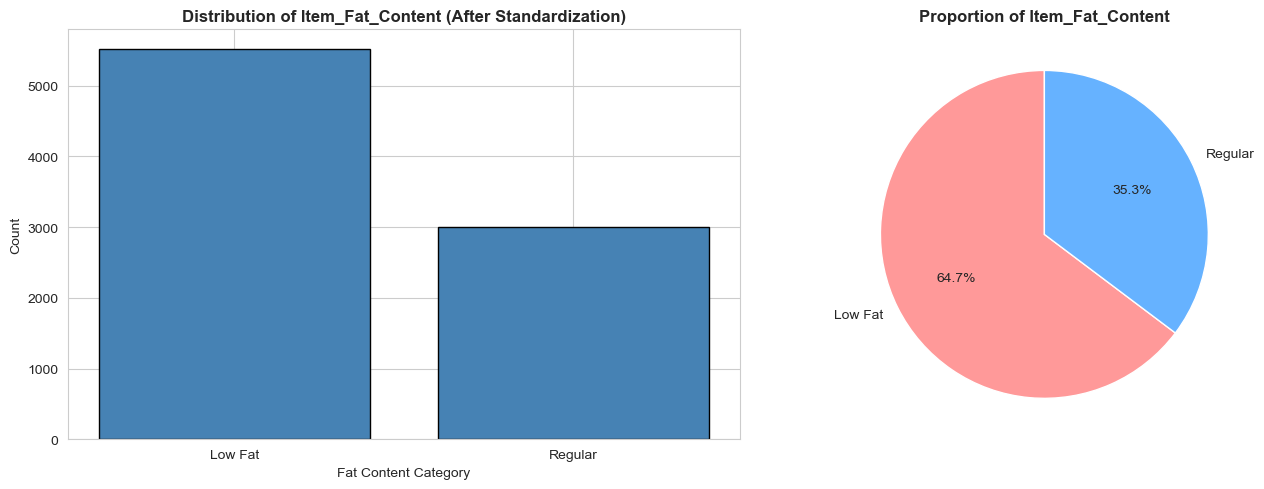

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fat_counts = df['Item_Fat_Content'].value_counts()

axes[0].bar(fat_counts.index, fat_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Item_Fat_Content (After Standardization)', fontweight='bold')
axes[0].set(ylabel='Count', xlabel='Fat Content Category')

axes[1].pie(fat_counts.values, labels=fat_counts.index, autopct='%1.1f%%', 
            colors=['#FF9999', '#66B2FF', '#99FF99'], startangle=90)
axes[1].set_title('Proportion of Item_Fat_Content', fontweight='bold')

plt.tight_layout()
plt.show()

## 1.2 Fixing Business Logic Errors
Relabeling non-consumable items (product codes starting with **'NC'**) as **'Non-Edible'** in `Item_Fat_Content`, since household goods cannot logically have a fat content.

In [6]:
# Fix business logic: Items starting with 'NC' are Non-Consumable
df.loc[df['Item_Identifier'].str.startswith('NC'), 'Item_Fat_Content'] = 'Non-Edible'
print("--- After Fixing Logic Errors ---")
print(df['Item_Fat_Content'].value_counts())

--- After Fixing Logic Errors ---
Item_Fat_Content
Low Fat       3918
Regular       3006
Non-Edible    1599
Name: count, dtype: int64


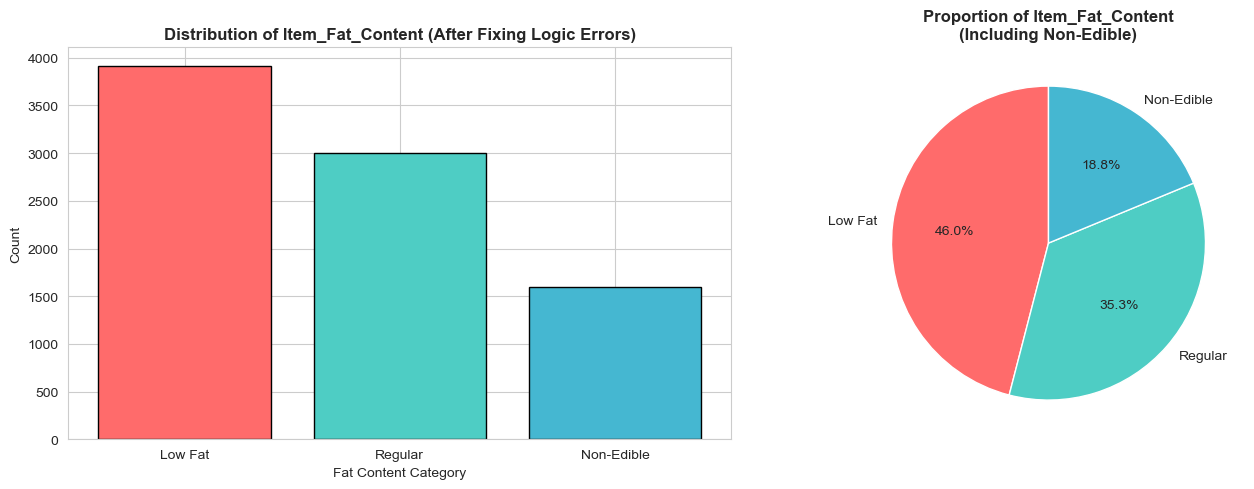

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fat_counts = df['Item_Fat_Content'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

axes[0].bar(fat_counts.index, fat_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Distribution of Item_Fat_Content (After Fixing Logic Errors)', fontweight='bold')
axes[0].set(ylabel='Count', xlabel='Fat Content Category')

axes[1].pie(fat_counts.values, labels=fat_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[1].set_title('Proportion of Item_Fat_Content\n(Including Non-Edible)', fontweight='bold')

plt.tight_layout()
plt.show()

## 1.3 Handling Placeholders (The 0.0 Issue)
Replacing physically impossible `0.0` values in `Item_Visibility` with `NaN`.

In [8]:
# Check the number of 0.0 values before processing
zeros_count = (df['Item_Visibility'] == 0).sum()
print("--- Before Processing: Item_Visibility ---")
print(f"Number of 0 values: {zeros_count}")
print(f"Total NaN values in Item_Visibility: {df['Item_Visibility'].isna().sum()}")
print("-" * 40)

# Replace 0 with NaN
df['Item_Visibility'] = df['Item_Visibility'].replace(0, np.nan)

# Verify the replacement
print("\n--- After Processing: Item_Visibility ---")
print(f"Number of 0 values: {(df['Item_Visibility'] == 0).sum()}")
print(f"Total NaN values in Item_Visibility: {df['Item_Visibility'].isna().sum()}")

--- Before Processing: Item_Visibility ---
Number of 0 values: 526
Total NaN values in Item_Visibility: 0
----------------------------------------

--- After Processing: Item_Visibility ---
Number of 0 values: 0
Total NaN values in Item_Visibility: 526


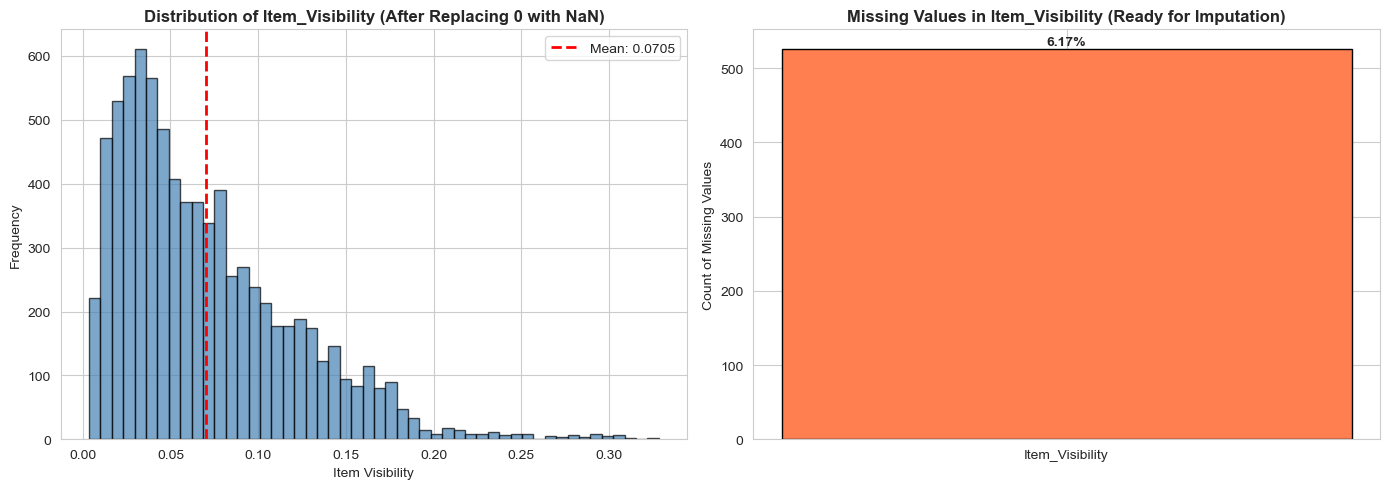

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Item_Visibility'].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Item_Visibility (After Replacing 0 with NaN)', fontweight='bold')
axes[0].set(xlabel='Item Visibility', ylabel='Frequency')
mean_val = df['Item_Visibility'].mean()
axes[0].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.4f}')
axes[0].legend()

missing_count = df['Item_Visibility'].isna().sum()
missing_pct = (missing_count / len(df)) * 100
axes[1].bar(['Item_Visibility'], [missing_count], color='coral', edgecolor='black')
axes[1].set_title('Missing Values in Item_Visibility (Ready for Imputation)', fontweight='bold')
axes[1].set_ylabel('Count of Missing Values')
axes[1].text(0, missing_count + 5, f'{missing_pct:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 1.4 Imputation for Missing Values
Applying grouped imputation for `Item_Weight` and `Item_Visibility` using the mean of their respective `Item_Identifier`. For `Outlet_Size`, we replace missing values with a new category **'Unknown'** to preserve data integrity and prevent severe bias.

In [10]:
# Check missing values before imputation
print("--- Before Imputation: Missing Values ---")
print(df[['Item_Weight', 'Item_Visibility', 'Outlet_Size']].isnull().sum())
print("-" * 40)

# 1. Impute 'Item_Weight' with the mean weight of the same 'Item_Identifier'
df['Item_Weight'] = df['Item_Weight'].fillna(
    df.groupby('Item_Identifier')['Item_Weight'].transform('mean')
)

# 2. Impute 'Item_Visibility' with the mean visibility of the same 'Item_Identifier'
df['Item_Visibility'] = df['Item_Visibility'].fillna(
    df.groupby('Item_Identifier')['Item_Visibility'].transform('mean')
)

# 3. Impute 'Outlet_Size' with a new category 'Unknown'
df['Outlet_Size'] = df['Outlet_Size'].fillna('Unknown')

# Verify the imputation
print("\n--- After Imputation: Missing Values ---")
print(df[['Item_Weight', 'Item_Visibility', 'Outlet_Size']].isnull().sum())
print("-" * 40)

# Verify the new category in Outlet_Size
print("\nDistribution of Outlet_Size including 'Unknown':")
print(df['Outlet_Size'].value_counts())

--- Before Imputation: Missing Values ---
Item_Weight        1463
Item_Visibility     526
Outlet_Size        2410
dtype: int64
----------------------------------------

--- After Imputation: Missing Values ---
Item_Weight        4
Item_Visibility    0
Outlet_Size        0
dtype: int64
----------------------------------------

Distribution of Outlet_Size including 'Unknown':
Outlet_Size
Medium     2793
Unknown    2410
Small      2388
High        932
Name: count, dtype: int64


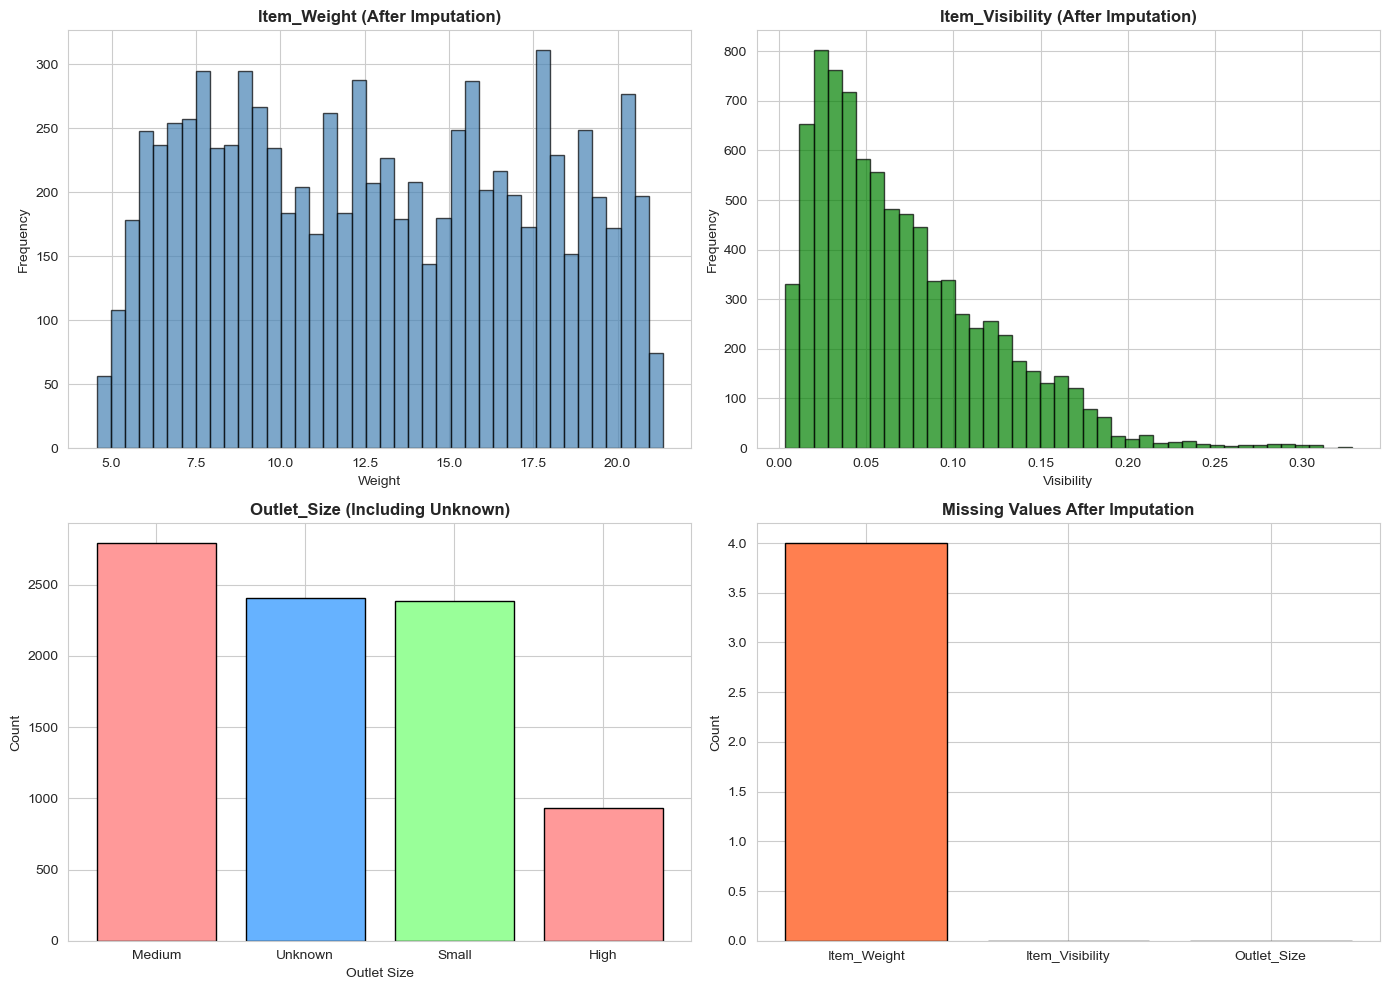

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['Item_Weight'], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Item_Weight (After Imputation)', fontweight='bold')
axes[0, 0].set(xlabel='Weight', ylabel='Frequency')

axes[0, 1].hist(df['Item_Visibility'], bins=40, color='green', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Item_Visibility (After Imputation)', fontweight='bold')
axes[0, 1].set(xlabel='Visibility', ylabel='Frequency')

outlet_counts = df['Outlet_Size'].value_counts()
axes[1, 0].bar(outlet_counts.index, outlet_counts.values, color=['#FF9999', '#66B2FF', '#99FF99'], edgecolor='black')
axes[1, 0].set_title('Outlet_Size (Including Unknown)', fontweight='bold')
axes[1, 0].set(ylabel='Count', xlabel='Outlet Size')

missing_counts = [df['Item_Weight'].isna().sum(), df['Item_Visibility'].isna().sum(), df['Outlet_Size'].isna().sum()]
axes[1, 1].bar(['Item_Weight', 'Item_Visibility', 'Outlet_Size'], missing_counts, color='coral', edgecolor='black')
axes[1, 1].set_title('Missing Values After Imputation', fontweight='bold')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

#### Investigating Residual Missing Values
After the primary imputation based on `Item_Identifier`, a few records (4 rows) remain missing for `Item_Weight`. This occurs because these specific products either appear only once in the dataset or lack weight data across all their occurrences.  

In [12]:
# Identify and display the remaining 4 rows with missing Item_Weight
residual_missing = df[df['Item_Weight'].isnull()]

print(f"Number of residual missing rows found: {len(residual_missing)}")
display(residual_missing)

Number of residual missing rows found: 4


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
927,FDN52,NaN,Regular,0.130933,Frozen Foods,86.9198,OUT027,1985,Medium,Tier 3,Supermarket Type3,1569.9564
1922,FDK57,NaN,Low Fat,0.079904,Snack Foods,120.0440,OUT027,1985,Medium,Tier 3,Supermarket Type3,4434.2280
4187,FDE52,NaN,Regular,0.029742,Dairy,88.9514,OUT027,1985,Medium,Tier 3,Supermarket Type3,3453.5046
5022,FDQ60,NaN,Regular,0.191501,Baking Goods,121.2098,OUT019,1985,Small,Tier 1,Grocery Store,120.5098


For the remaining 4 items where `Item_Identifier` did not have a historical weight record, we apply a fallback imputation using the **Mean** weight of their respective **`Item_Type`**. This ensures 100% data completeness without losing valuable sales observations.

In [13]:
# Apply fallback imputation for the 4 stubborn NaN values
df['Item_Weight'] = df['Item_Weight'].fillna(
    df.groupby('Item_Type')['Item_Weight'].transform('mean')
)

# Final verification to ensure 0 missing values
print("--- Final Missing Value Count ---")
print(df[['Item_Weight', 'Item_Visibility', 'Outlet_Size']].isnull().sum())

--- Final Missing Value Count ---
Item_Weight        0
Item_Visibility    0
Outlet_Size        0
dtype: int64


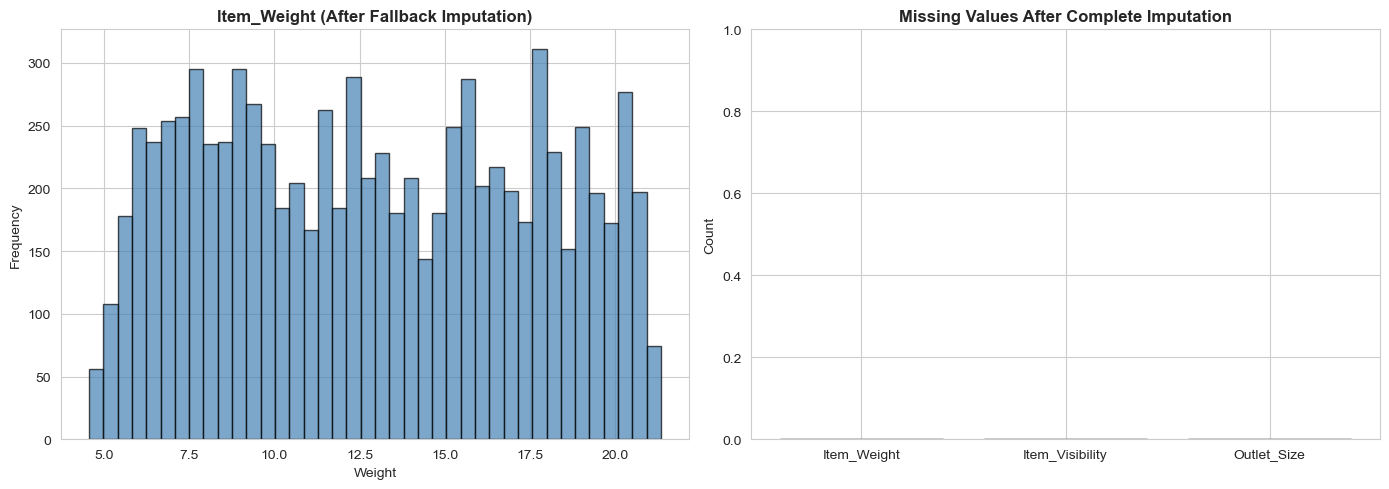

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Item_Weight'], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Item_Weight (After Fallback Imputation)', fontweight='bold')
axes[0].set(xlabel='Weight', ylabel='Frequency')

missing_after_fallback = df[['Item_Weight', 'Item_Visibility', 'Outlet_Size']].isnull().sum()
axes[1].bar(missing_after_fallback.index, missing_after_fallback.values, color='green', edgecolor='black')
axes[1].set_title('Missing Values After Complete Imputation', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 1.5 Feature Engineering: Outlet Age
The `Outlet_Establishment_Year` represents the year a store was opened. However, for a predictive model, the **age of the outlet** (years of operation) is a more meaningful feature. We will calculate the outlet's age relative to the year the data was collected (2013).

In [15]:
# Calculate the age of the outlet based on the data collection year (2013)
df['Outlet_Years'] = 2013 - df['Outlet_Establishment_Year']

# Verify the new column
print("--- After Feature Engineering: Outlet_Years ---")
print(df[['Outlet_Establishment_Year', 'Outlet_Years']])
print("-" * 40)

# Check the distribution of years
print(df['Outlet_Years'].describe())

--- After Feature Engineering: Outlet_Years ---
      Outlet_Establishment_Year  Outlet_Years
0                          1999            14
1                          2009             4
2                          1999            14
3                          1998            15
4                          1987            26
...                         ...           ...
8518                       1987            26
8519                       2002            11
8520                       2004             9
8521                       2009             4
8522                       1997            16

[8523 rows x 2 columns]
----------------------------------------
count    8523.000000
mean       15.168133
std         8.371760
min         4.000000
25%         9.000000
50%        14.000000
75%        26.000000
max        28.000000
Name: Outlet_Years, dtype: float64


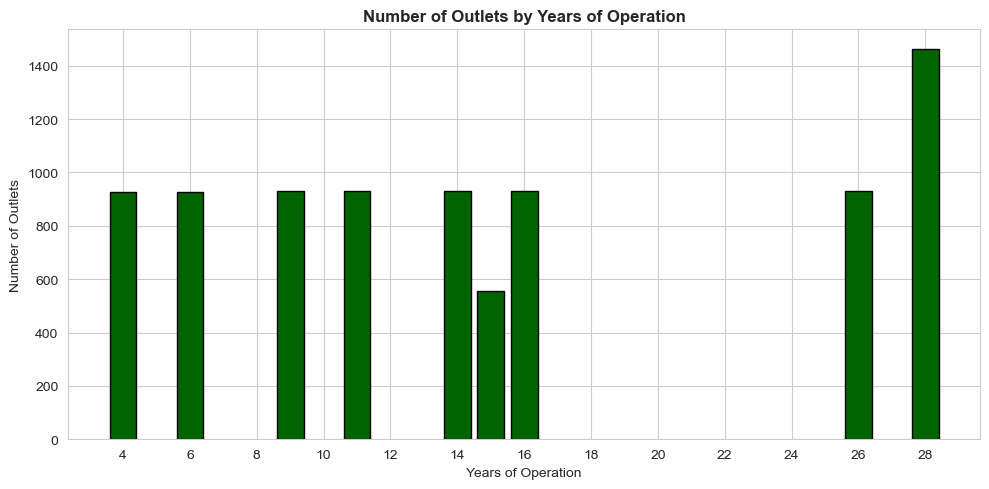

In [16]:
# Plot bar chart: Number of outlets by years of operation (x-axis step=2)
outlet_years_counts = df['Outlet_Years'].value_counts().sort_index()
plt.figure(figsize=(10,5))
plt.bar(outlet_years_counts.index, outlet_years_counts.values, color='darkgreen', edgecolor='black')
plt.title('Number of Outlets by Years of Operation', fontweight='bold')
plt.xlabel('Years of Operation')
plt.ylabel('Number of Outlets')
plt.xticks(ticks=range(int(outlet_years_counts.index.min()), int(outlet_years_counts.index.max())+1, 2))
plt.tight_layout()
plt.show()

## 1.6 Dropping Irrelevant Features
To streamline the dataset for machine learning, we remove columns that are either redundant or do not contribute predictive value:
* **`Outlet_Establishment_Year`**: Replaced by the more meaningful `Outlet_Years`.
* **`Item_Identifier`**: A unique ID with high cardinality that does not provide generalizable patterns for the model.

In [17]:
# List of columns to drop
cols_to_drop = ['Item_Identifier', 'Outlet_Establishment_Year']

# Drop the columns
df.drop(columns=cols_to_drop, inplace=True)

# Verify the final structure of the cleaned dataset
print("--- Final Columns After Cleaning ---")
print(df.columns.tolist())
print("-" * 40)
print(f"Current Shape: {df.shape}")
display(df)

--- Final Columns After Cleaning ---
['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Outlet_Sales', 'Outlet_Years']
----------------------------------------
Current Shape: (8523, 11)


,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Years
0,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,Medium,Tier 1,Supermarket Type1,3735.1380,14
1,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,Medium,Tier 3,Supermarket Type2,443.4228,4
2,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,Medium,Tier 1,Supermarket Type1,2097.2700,14
3,19.200,Regular,0.022911,Fruits and Vegetables,182.0950,OUT010,Unknown,Tier 3,Grocery Store,732.3800,15
4,8.930,Non-Edible,0.016164,Household,53.8614,OUT013,High,Tier 3,Supermarket Type1,994.7052,26
...,...,...,...,...,...,...,...,...,...,...,...
8518,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,High,Tier 3,Supermarket Type1,2778.3834,26
8519,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,Unknown,Tier 2,Supermarket Type1,549.2850,11
8520,10.600,Non-Edible,0.035186,Health and Hygiene,85.1224,OUT035,Small,Tier 2,Supermarket Type1,1193.1136,9
8521,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,Medium,Tier 3,Supermarket Type2,1845.5976,4


# 2. Dataset Splitting (Train-Test Split)
* **Description**: We split the dataset into two independent sets: **Training (80%)** and **Testing (20%)** using `train_test_split`.

* **Reasoning**: Splitting the data before any transformations (like Scaling or Log) is the best practice to prevent **Data Leakage**. This ensures that the test set remains completely unseen, allowing us to evaluate the model's performance on truly "new" data.

In [18]:
# Define Features (X) and Target (y)
# We use the raw cleaned data before scaling/log transformation
X = df.drop(columns=['Item_Outlet_Sales'])
y = df['Item_Outlet_Sales']

# Split into Train (80%) and Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verify the split
print(f"Dataset successfully split:")
print(f"- Training samples: {X_train.shape[0]}")
print(f"- Testing samples:  {X_test.shape[0]}")

Dataset successfully split:
- Training samples: 6818
- Testing samples:  1705


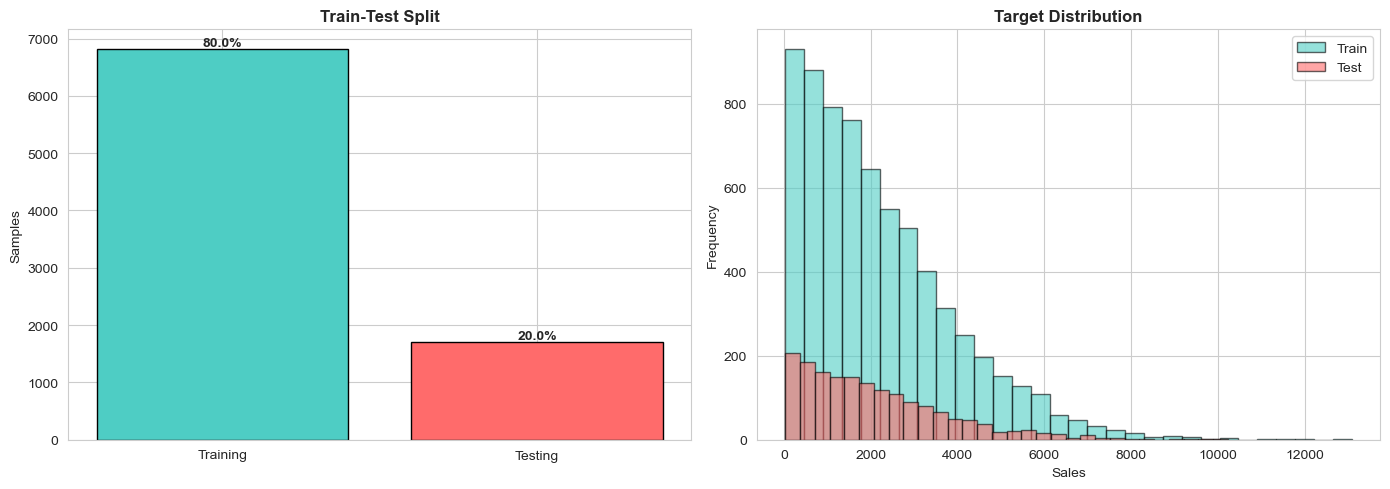

✓ Splitting Complete: Train 6818 | Test 1705


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_size, test_size = X_train.shape[0], X_test.shape[0]
axes[0].bar(['Training', 'Testing'], [train_size, test_size], color=['#4ECDC4', '#FF6B6B'], edgecolor='black')
axes[0].set_title('Train-Test Split', fontweight='bold')
axes[0].set_ylabel('Samples')
for i, v in enumerate([train_size, test_size]):
    pct = (v / (train_size + test_size)) * 100
    axes[0].text(i, v + 50, f'{pct:.1f}%', ha='center', fontweight='bold')

axes[1].hist(y_train, bins=30, alpha=0.6, label='Train', color='#4ECDC4', edgecolor='black')
axes[1].hist(y_test, bins=30, alpha=0.6, label='Test', color='#FF6B6B', edgecolor='black')
axes[1].set_title('Target Distribution', fontweight='bold')
axes[1].set(xlabel='Sales', ylabel='Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"✓ Splitting Complete: Train {X_train.shape[0]} | Test {X_test.shape[0]}")

**Saving Processed Data**

In [20]:
# Combine X and y for both sets
train_processed = pd.concat([X_train, y_train], axis=1)
test_processed = pd.concat([X_test, y_test], axis=1)

# Save to CSV without the index column
train_processed.to_csv('../data/train_data/train.csv', index=False)
test_processed.to_csv('../data/test_data/test.csv', index=False)

print("Processed data successfully saved to data folder.")

Processed data successfully saved to data folder.
